<a href="https://colab.research.google.com/github/zlwym/MannZoe_IAT461_Assignment2/blob/main/iat461_a2_ZoeMann_301452821.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `[Zoe Mann]`  
**SFU ID:** `[301452821]`  
**Date:** `[July 5]`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import loguniform

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [ ]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na=False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [ ]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U79488,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


There are 2000 entries in this dataset in total. There is nearly a 50/50 split between control and treatment users, with 1011 users in the control group and 989 in the treatment group.

In [ ]:
# Missing values
df_ab.isnull().sum()


,0
user_id,0
ab_group,0
device_type,0
account_age_days,0
prior_whiteboard_sessions,0
plan_region,0
num_collaborators,0
feature_tour_completed,0
templates_used,0
ai_suggestions_used,0


There are no missing values to take care of.

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


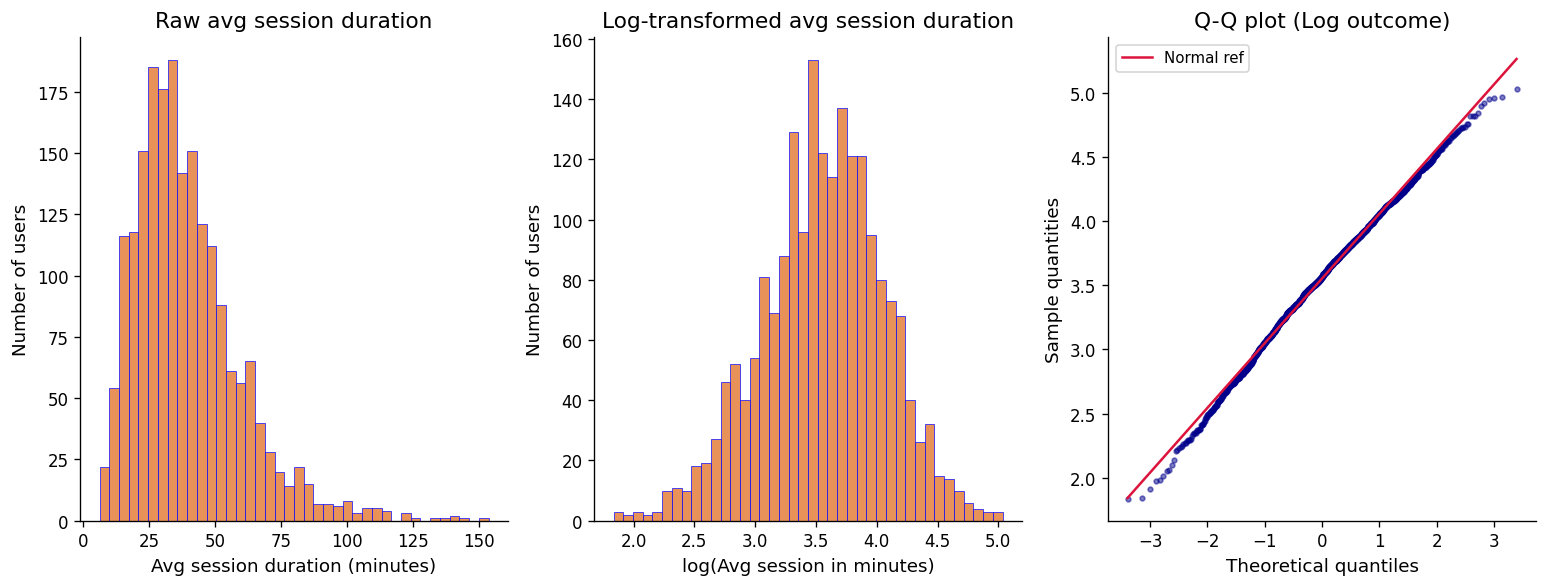

Skewness - raw outcome : 1.3768
Skewness - log outcome : -0.2135
(R^2 of Q-Q fit)       : 0.9969


In [ ]:
y_raw = df_ab['avg_whiteboard_session_duration_min']
y_log = np.log(y_raw)

fig, axes = plt.subplots(1, 3, figsize=(13,5))

axes[0].hist(y_raw, bins=40, color=ACCENT, edgecolor='blue', linewidth = 0.4)
axes[0].set_title('Raw avg session duration')
axes[0].set_xlabel('Avg session duration (minutes)')
axes[0].set_ylabel('Number of users')

#Log transformed
axes[1].hist(y_log, bins=40, color=ACCENT, edgecolor='blue', linewidth = 0.4)
axes[1].set_title('Log-transformed avg session duration')
axes[1].set_xlabel('log(Avg session in minutes)')
axes[1].set_ylabel('Number of users')

#Q-Q plot
#osm: order statistic medians, theoretical quantiles
#osr: ordered sample ranks, actual distribution for log transformed
#slope and intercept: reference line
#r: correlation coefficient between osm and osr
(osm, osr), (slope, intercept, r) = stats.probplot(y_log, dist='norm')
axes[2].scatter(osm, osr, color = 'darkblue', s=8, alpha=0.5)
axes[2].plot(osm, slope * np.array(osm) + intercept, color='crimson', lw=1.5, label = 'Normal ref')
axes[2].set_title('Q-Q plot (Log outcome)')
axes[2].set_xlabel('Theoretical quantiles')
axes[2].set_ylabel('Sample quantities')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

skew_raw = float(y_raw.skew())
skew_log = float(y_log.skew())
print(f"Skewness - raw outcome : {skew_raw:.4f}")
print(f"Skewness - log outcome : {skew_log:.4f}")
print(f"(R^2 of Q-Q fit)       : {r**2:.4f}")

**✏️ Your interpretation (A1.1):**

*Replace this text. Is the log-transformed outcome more normally distributed? How does the Q-Q plot support your conclusion? Will you use the raw or log outcome in your model?*


The log-transformed outcome is more normally distributed than the raw version. In the raw average session duration chart, the data is right-skewed with a skewness of 1.38. The log transformed avgerage session duration chart has a skewness of only -0.21.

The Q-Q plot confirms this because the log-transformed values are very close to the reference line, which is 0.9960.

I'll be using the log outcome for my model because linear regression works better with normally distributed data.

Reading these graphs, I can be pretty confident that this is normal behaviour for users by looking at the amount of minutes most users spent on Phigma in a session.

#### A1.2 — Examine the confounders

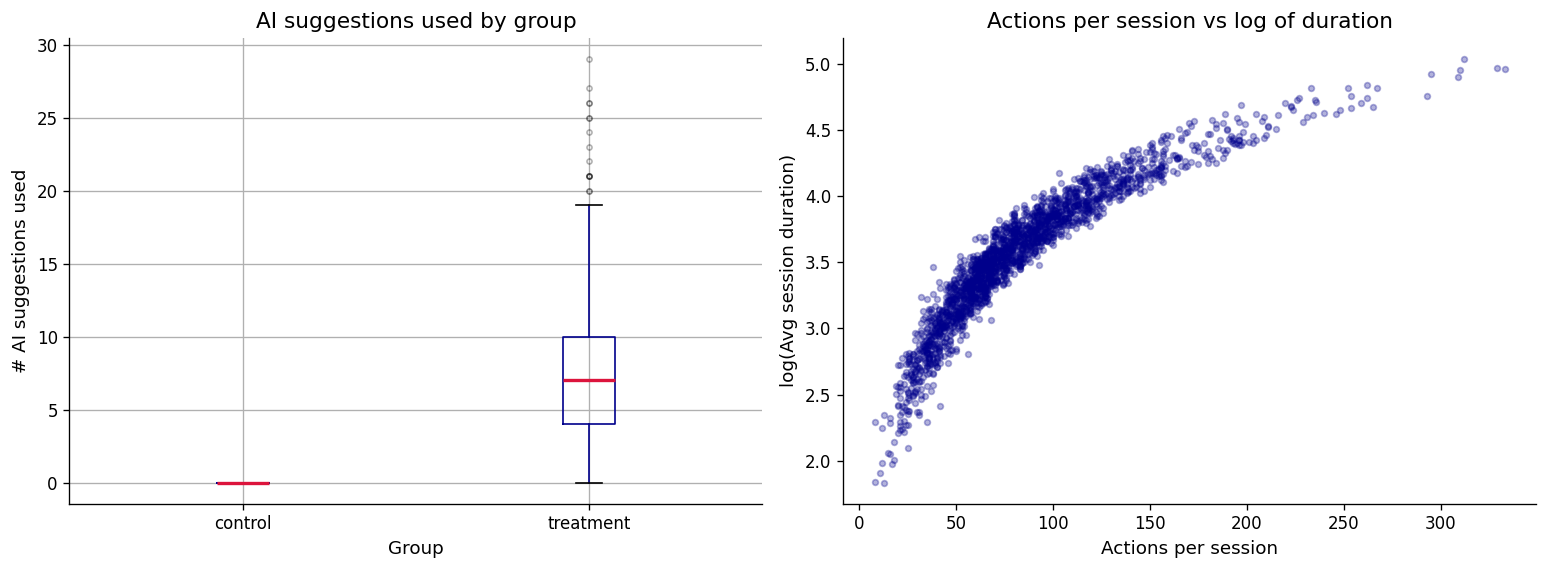

Pearson r (whiteboard_actions_per_session vs log_duration): 0.9136

Descriptive stats for ai_suggestions_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Left boxplot of AI suggestions
df_ab.boxplot(column='ai_suggestions_used', by='ab_group', ax=axes[0],
    boxprops = dict(color='darkblue'), medianprops = dict(color='crimson', lw=2),
    whiskerprops=dict(color='darkblue'), capprops=dict(color='black'),
    flierprops=dict(marker='o', color='blue', alpha=0.3, markersize=3)
    )
axes[0].set_title("AI suggestions used by exp group")
axes[0].set_xlabel('Group')
axes[0].set_ylabel('# AI suggestions used')
plt.sca(axes[0]);
plt.title("AI suggestions used by group")
plt.suptitle('')

#Scatterplot of white_board actions per session vs log(duration)

log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])
axes[1].scatter(df_ab['whiteboard_actions_per_session'], log_dur, color='darkblue',
                alpha=0.3, s=12
                )
axes[1].set_title("Actions per session vs log of duration")
axes[1].set_xlabel('Actions per session')
axes[1].set_ylabel('log(Avg session duration)')

plt.tight_layout()
plt.show()

corr_actions = df_ab['whiteboard_actions_per_session'].corr(log_dur)
print(f'Pearson r (whiteboard_actions_per_session vs log_duration): {corr_actions:.4f}')

print("\nDescriptive stats for ai_suggestions_used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))



**✏️ Your interpretation (A1.2):**

*Replace this text. What do you notice about `ai_suggestions_used` across the two groups? What does the correlation between `whiteboard_actions_per_session` and the outcome suggest? Why should neither be included in your model?*


In the boxplot chart, I can see that there are no AI suggestions for the control group, which makes sense as the study only provided the treatment group with AI suggestions.

The median is about 7 for the treatment group with multiple outliers, such as people using over 20 suggestions or people who haven't used suggestions at all. The expected maximum of AI suggestions used is around 18 for the treatment group.

The 2nd plot shows the distribution of average session duration vs actions per session, and it follows a logarithmic distribution. When the number of actions increases, the average session duration also increases following a logarithmic path. It "drops off" at a point where actions per session doesn't affect duration as much, but at the start it increases rapidly.

AI suggestions used shouldn't be included as a predictor because only users in the treatment group used the AI suggestions. The model would likely default to classifying all users who didn't use AI suggestions as control group users, even though it's clear that some treatment group users didn't use AI suggestions either.

Whiteboard actions per session should also not be used in the model because the correlation with the outcome is strong with a Pearson's r of 0.91. This makes sense, as the more actions per session, the longer the whiteboard session. This variable doesn't really matter because this is just natural behaviour and doesn't tell us much, so it shouldn't be used as a predictor.

#### A1.3 — Predictor distributions and relationships with outcome

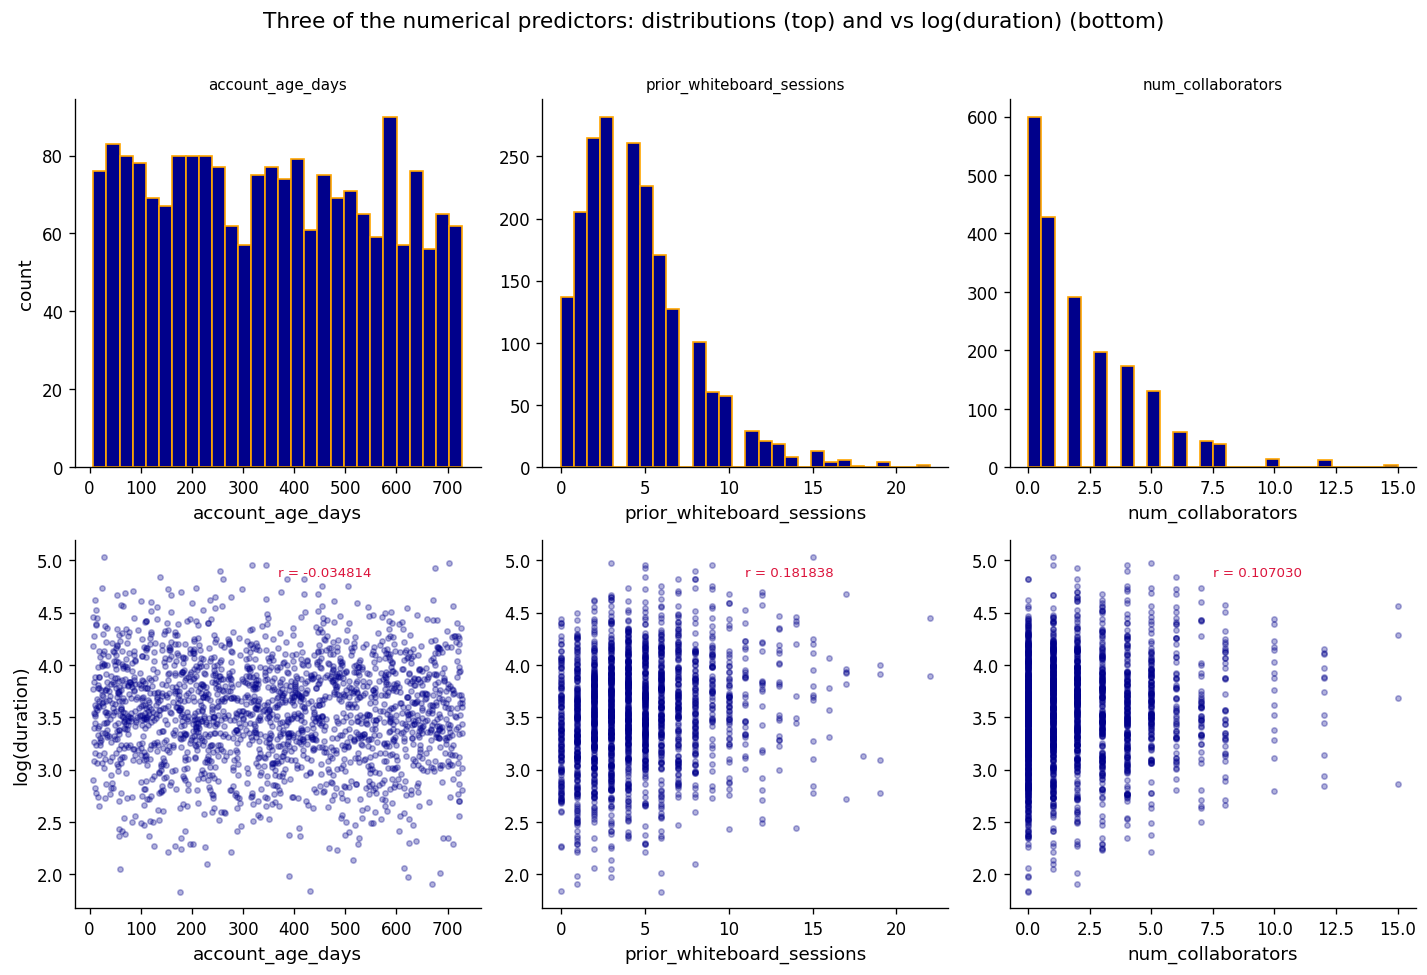

In [ ]:
num_predictors = [
    'account_age_days',
    'prior_whiteboard_sessions',
    'num_collaborators'
]

n = len(num_predictors)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
fig.suptitle('Three of the numerical predictors: distributions (top) and vs log(duration) (bottom)',
             fontsize=13, y=1.01)

for j, col in enumerate(num_predictors):
  #Top row: histogram
  axes[0, j].hist(df_ab[col], bins=28, color='darkblue', edgecolor='orange', lw=0.4)
  axes[0, j].set_title(col, fontsize=9)
  axes[0, j].set_xlabel(col)
  axes[0, j].set_ylabel('count' if j == 0 else '')

  #Bottom row: scatterplot
  r = df_ab[col].corr(log_dur)
  axes[1, j].scatter(df_ab[col], log_dur, color='darkblue', alpha=0.3, s=10)
  axes[1, j].set_xlabel(col)
  axes[1, j].set_ylabel('log(duration)' if j == 0 else '')
  axes[1, j].annotate(f'r = {r:2f}', xy=(0.5, 0.9),
                      xycoords='axes fraction', fontsize = 8, color='crimson')

plt.tight_layout()
plt.show()

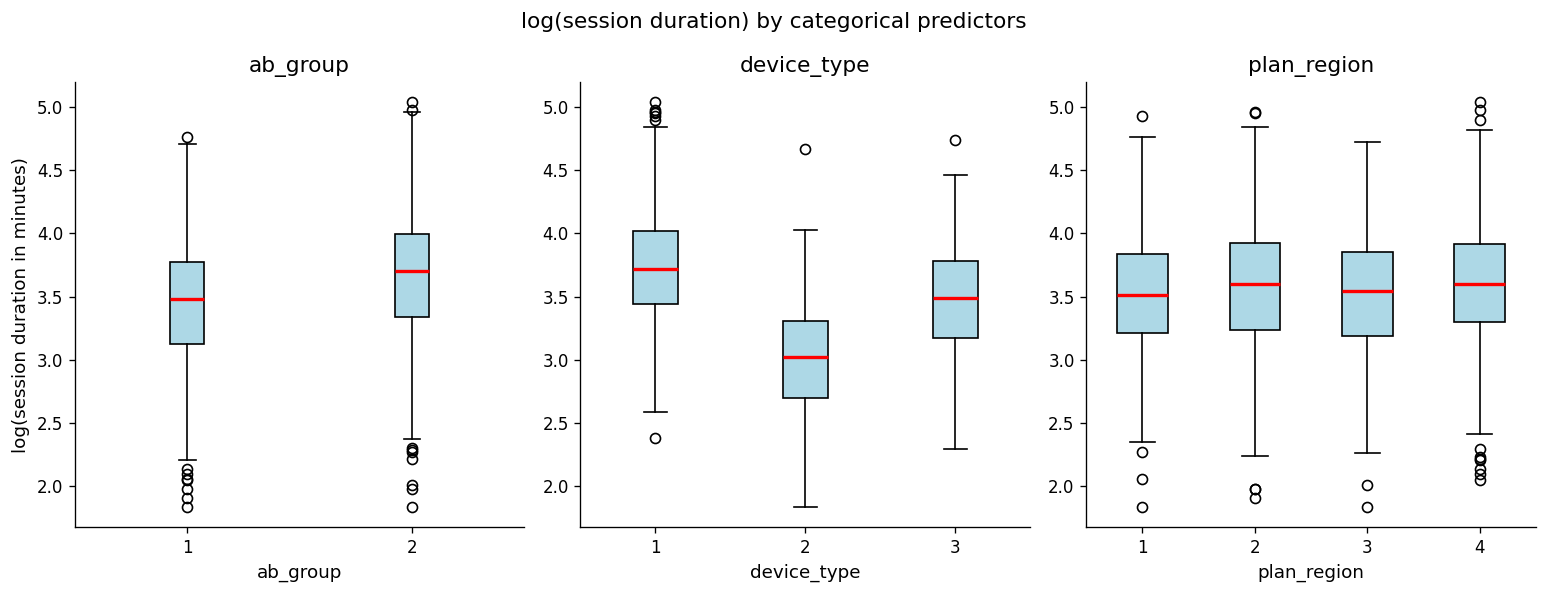

In [ ]:
cat_predictors = ['ab_group', 'device_type', 'plan_region']

log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])

fig, axes = plt.subplots(1,  len(cat_predictors), figsize = (13, 5))
fig.suptitle('log(session duration) by categorical predictors', fontsize = 13)

for j, col in enumerate(cat_predictors):
  levels = sorted(df_ab[col].unique())
  grouped = [log_dur[df_ab[col] == lvl].values for lvl in levels] #if the column is equal to levels, group all the rows whose device type is the same
  axes[j].boxplot(grouped, label=levels, patch_artist = True,
                  boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', lw=2))
  axes[j].set_title(col)
  axes[j].set_xlabel(col)
  axes[j].set_ylabel('log(session duration in minutes)' if j == 0 else '')
  axes[j].tick_params(axis='x')

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A1.3):**

*3–5 sentences summarizing your EDA. Which predictors look most promising? Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?*


Here, I have explored account_age_days, prior_whiteboard_sessions, num_collaborators, ab_group, device_type, and plan_region.

From this EDA, I can see that prior whiteboard sessions, number of collaborators, and device type are the most promising. For prior whiteboard sessions and number of collaborators, the scatterplots show that it's worth log-transforming this data. The original charts show right skewed distributions.

The boxplot for device_type shows that device type impacts session duration, which makes sense because we don't really expect a person using a mobile device to spend a long time on Phigma.

For the boxplots, we used this type of chart because this is categorical rather than numeric data. This way, we can see the distribution of session duration minutes for each of the categories.

I left out user_id and the raw values for session_duration_min. For user_id, we don't really care about the identier because it doesn't predict anything. For raw session_duration_min, we don't need these because they also are not a predictor.

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
df_ab['ab_group_enc'] = (df_ab['ab_group'] == 'treatment').astype(int) #new column

device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device', drop_first = True).astype(int)

region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region', drop_first = True).astype(int)

log_account_age = np.log1p(df_ab['account_age_days'])
log_prior_whiteboard_sessions = np.log1p(df_ab['prior_whiteboard_sessions'])
log_num_collaborators = np.log1p(df_ab['num_collaborators'])


X =pd.concat([
    df_ab['ab_group_enc'].rename('ab_group'),
    log_account_age.rename('log_acount_age_days'),
    log_prior_whiteboard_sessions.rename('log_whiteboard_sessions'),
    log_num_collaborators.rename('log_num_collaborators'),
    device_dummies,
    region_dummies

    ], axis = 1)

y = np.log(df_ab['avg_whiteboard_session_duration_min'])

assert X.isnull().sum().sum() == 0
print(f'Feature matrix shape: {X.shape}')
print(f"Missing values in X:  {X.isnull().sum().sum()}")
print(f'\nFeature columns: \n{X.columns.tolist()}')

X.head(3)

#Explore this more

Feature matrix shape: (2000, 9)
Missing values in X:  0

Feature columns: 
['ab_group', 'log_acount_age_days', 'log_whiteboard_sessions', 'log_num_collaborators', 'device_mobile', 'device_tablet', 'region_EU', 'region_LATAM', 'region_NA']


,ab_group,log_acount_age_days,log_whiteboard_sessions,log_num_collaborators,device_mobile,device_tablet,region_EU,region_LATAM,region_NA
0,0,6.171701,1.609438,1.386294,0,1,1,0,0
1,0,6.452049,2.302585,0.693147,0,0,0,0,0
2,0,5.075174,2.397895,1.791759,0,0,0,0,1


**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*


**ab_group**

This is the primary variable in the study which indicates whether or not the user received the AI feature or not.

The following features are included because they are pre-existing conditions from before the experiment, meaning the experiment didn't decide these conditions for the users. These features will let the model understand if access to Phigma AI impacted whiteboard session duration among users, because there could be patterns extrapolated from these features. Features not included avoids data that was measured after treatment in the study, or data that directly reflected the outcome.

**log_account_age_days**

This feature uses the log-transformed data because its original distribution was right-skewed.

**log_whiteboard_sessions**

The prior whiteboard sessions data is log-transformed to normalize the skewed data. This better captures previous user behaviour.

**log_num_collaborators**

This data has also been log-transformed because of its skewed distribution.

**device_dummies**

This contains categorical data about which device type the user used. This is either tablet, mobile, or desktop. Device type has an impact on session duration and should be included.

**region_dummies**

This contains categorical data about which geographical region a user is from. It may have an impact on session duration and AI suggestion use, as users from one region may have different behaviours.

### A3 — OLS Regression


In [ ]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.358
Model:                                             OLS   Adj. R-squared:                  0.355
Method:                                  Least Squares   F-statistic:                     123.1
Date:                                 Mon, 06 Jul 2026   Prob (F-statistic):          4.14e-184
Time:                                         05:44:21   Log-Likelihood:                -1028.8
No. Observations:                                 2000   AIC:                             2078.
Df Residuals:                                     1990   BIC:                             2134.
Df Model:                                            9                                         
Covariance Type:                             nonrobust                                         
                              coef    st

#### A3.1 — Interpret the model

In [ ]:
print(f'R²      = {model_ols.rsquared:.4f}')
print(f'Adj. R² = {model_ols.rsquared_adj:.4f}')
print()

ab_coef = model_ols.params['ab_group']
ab_pval = model_ols.pvalues['ab_group']

#y = log(duration)

ab_pct_change = (np.exp(ab_coef) - 1)

control_mean = df_ab.loc[df_ab['ab_group'] == 'control', 'avg_whiteboard_session_duration_min'].mean()

ab_mins_effect = control_mean * (np.exp(ab_coef) - 1) #converts percentage effect into minutes

print(f'ab_group coefficient : {ab_coef:.4f}')
print(f'ab_group p-value     : {ab_pval:.4f}')
print(f"Back-transformed.    : {ab_pct_change:.1f}% relative to control mean")
print(f"                     : ~= {ab_mins_effect:1f} min above control mean ({control_mean:1f} min)")

# 0.217 == exp(0.217) = 1.242
# experimental group has 1.242 times the usage of the control group
# increase in z 1.242 - 1 = 0.242
# 24.2%

#significant predictors with p < 0.05
sig = model_ols.pvalues[model_ols.pvalues < 0.05].sort_values()
print('significant predictors: ')
for var, pv in sig.items():
  coef = model_ols.params[var]
  print(f'. {var:<35s}.  coef = {coef:.4f}.   p={pv:.4f}')

R²      = 0.3576
Adj. R² = 0.3547

ab_group coefficient : 0.2170
ab_group p-value     : 0.0000
Back-transformed.    : 0.2% relative to control mean
                     : ~= 8.519442 min above control mean (35.160930 min)
significant predictors: 
. const                              .  coef = 3.3722.   p=0.0000
. device_mobile                      .  coef = -0.7257.   p=0.0000
. ab_group                           .  coef = 0.2170.   p=0.0000
. device_tablet                      .  coef = -0.2579.   p=0.0000
. log_whiteboard_sessions            .  coef = 0.1407.   p=0.0000
. log_num_collaborators              .  coef = 0.0861.   p=0.0000
. region_NA                          .  coef = 0.0826.   p=0.0005
. region_EU                          .  coef = 0.0768.   p=0.0018


**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*


The users in the treatment group had significantly longer whiteboard sessions than users in the control group. We can see this in the regression coefficient for ab_group, which is 0.217, and p value which is lesser than 0.001. The treatment group had about 8.5 minutes longer use than the control group did.

The R^2 of 0.358 means that the regression model explained about 35.8% of the variation between average whiteboard session duration.

Prior whiteboard activity and the number of collaborators were also good predictors of session duration, as can be seen by their regression coefficients and p values of less than 0.001. This suggests that more engaged users spend longer on Phigma. I can also see that mobile and tablet users had significantly shorter sessions than desktop users. This makes sense, as most people using software like Phigma do the majority of the work on desktop devices rather than mobile ones.

#### A3.2 — Regression diagnostics

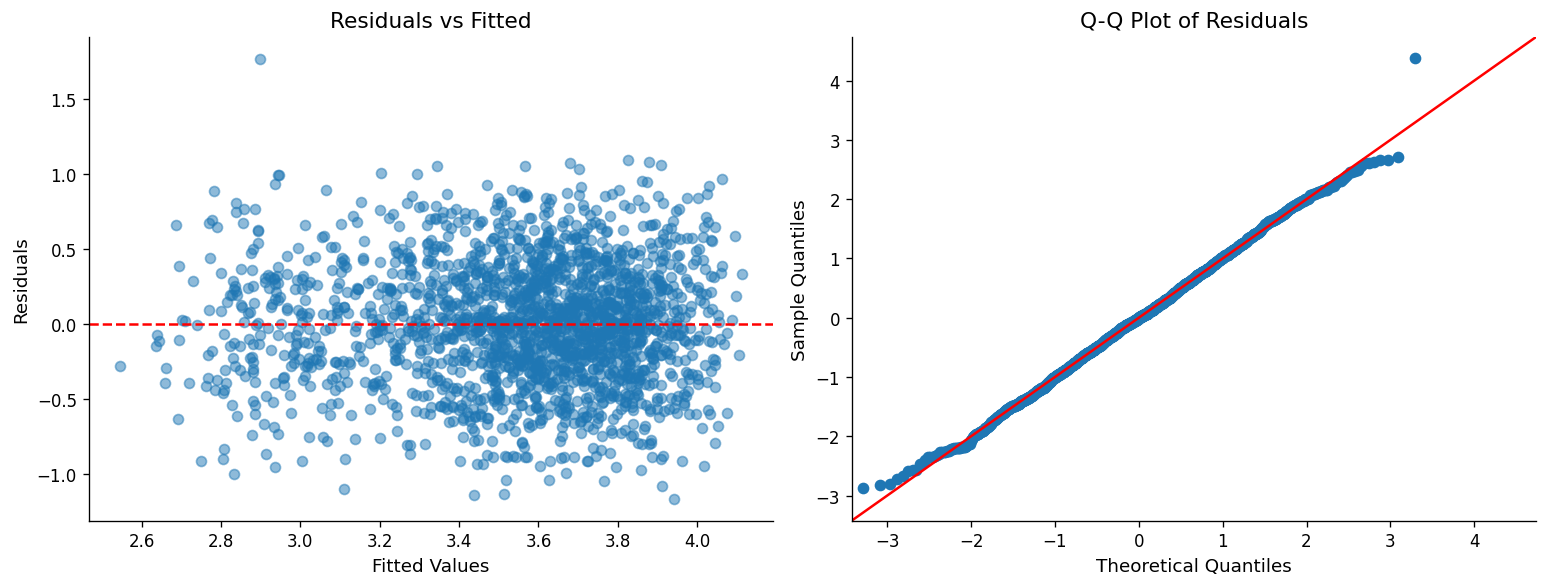

In [ ]:
predictions = model_ols.fittedvalues
residuals = model_ols.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#residuals vs fitted

axes[0].scatter(predictions, residuals, alpha = 0.5)

axes[0].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

#Q-Q plot

sm.qqplot(
    residuals,
    fit=True,
    line='45',
    ax=axes[1]
)

axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*


The residuals do look randomly scattered around zero. There isn't a pattern I can pick out which means that the linearity assumption is satisfied. The spread of residuals is pretty consistent across fitted values, with some minor evidence of changing variance.

The Q-Q plot of residuals follows the reference line very closely. This means that the residuals are normally distributed. These plots tell us that the assumptions of ols regression are decently well satisfied for this model.

### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*


I'm going to be using ab_group x prior_whiteboard_sessions.

My hypothesis is that access to the AI feature would have a larger positive impact on users with more previous whiteboard sessions, since experienced users may be more likely to use the AI feature as they are already familiar with Phigma. I think that people with higher previous usage of Phigma will benefit more from the AI feature.

In [ ]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())

df_ab['ab_x_prior_sessions'] = (
    df_ab['ab_group_enc'] *
    df_ab['prior_whiteboard_sessions']
)

X_interaction = X.copy()
X_interaction['ab_x_prior_sessions'] = df_ab['ab_x_prior_sessions']

X_interaction_const = sm.add_constant(X_interaction)
model_interaction = sm.OLS(y, X_interaction_const).fit()
print(model_interaction.summary())

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.358
Model:                                             OLS   Adj. R-squared:                  0.355
Method:                                  Least Squares   F-statistic:                     111.0
Date:                                 Mon, 06 Jul 2026   Prob (F-statistic):          1.81e-183
Time:                                         05:44:21   Log-Likelihood:                -1027.9
No. Observations:                                 2000   AIC:                             2078.
Df Residuals:                                     1989   BIC:                             2139.
Df Model:                                           10                                         
Covariance Type:                             nonrobust                                         
                              coef    st

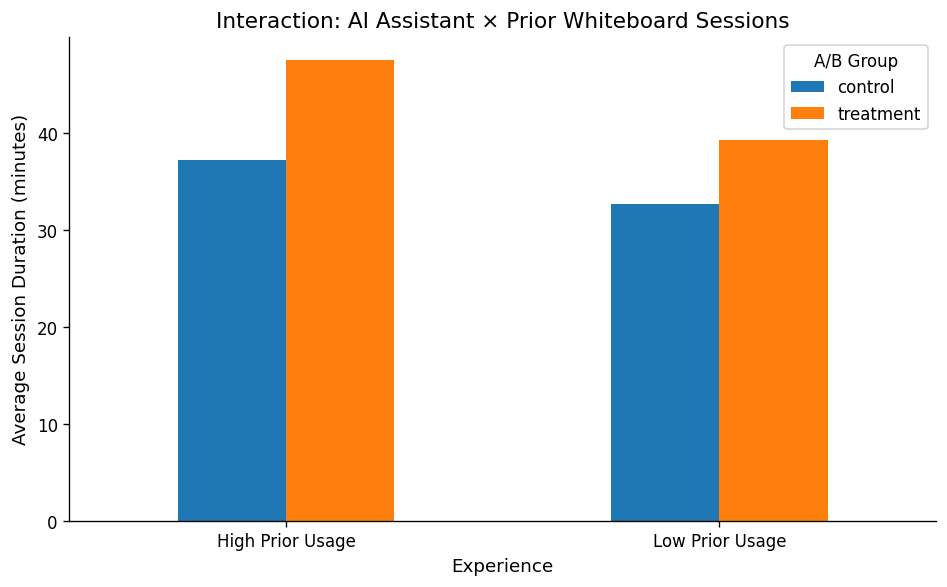

In [ ]:
# Create low/high experience groups
median_sessions = df_ab["prior_whiteboard_sessions"].median()

df_plot = df_ab.copy()

df_plot["Experience"] = np.where(
    df_plot["prior_whiteboard_sessions"] >= median_sessions,
    "High Prior Usage",
    "Low Prior Usage"
)

mean_values = (
    df_plot
    .groupby(["Experience", "ab_group"])["avg_whiteboard_session_duration_min"]
    .mean()
    .unstack()
)

mean_values.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Session Duration (minutes)")
plt.title("Interaction: AI Assistant × Prior Whiteboard Sessions")
plt.xticks(rotation=0)
plt.legend(title="A/B Group")
plt.tight_layout()
plt.show()

**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*


The interaction between treatment/control assignment and prior whiteboard sessions was not statistically significant, as the regression coefficient is 0.007 and the p-value is 0.164, which is greater than 0.05. This means that the AI feature didn't offer any meaningful benefit to users depending on their level of prior usage.

For Phigma, this means that they can confidently roll out the feature to all users, rather than targeting users of a specific prior whiteboard usage level. Since the evidence suggests that no single group benefits most from the AI feature a significant amount, everyone can have access to it.

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [ ]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                         object
signup_date                     object
first_session_date              object
device_type                     object
country_tier                    object
referral_source                 object
num_sessions_30d                 int64
total_time_min_30d               int64
projects_created_30d             int64
exports_30d                      int64
collaborators_invited_30d        int64
support_tickets_30d              int64
used_premium_feature_preview     int64
ai_assistant_sessions_30d        int64
subscribed                       int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [ ]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [ ]:
# YOUR CODE HERE

# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] > 0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d'],
    0
)

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True, dtype=int)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True, dtype=int)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)
df_sub['country_tier_enc'] = df_sub['country_tier'].map({
    'tier_1':1,
    'tier_2':2,
    'tier_3':3
    })

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)

X_sub = pd.concat([
    df_sub.drop(columns=[
        'user_id',
        'signup_date',
        'first_session_date',
        'device_type',
        'referral_source',
        'country_tier',
        'subscribed'
    ]),
    device_dummies2,
    referral_dummies
], axis=1)

y_sub = df_sub['subscribed']

# Confirm
print(f"Any inf: {np.isinf(X_sub.values).any()}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")

X_sub.head(3)


Any inf: False
Any NaN: False
Feature matrix shape: (3000, 17)


,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,1,96,1,0,0,0,1,6,5,96.0000,0,1,0,1,0,0,0
1,15,267,8,1,5,0,0,0,0,17.8000,0,2,0,1,0,0,1
2,16,263,0,0,3,3,1,4,14,16.4375,0,1,0,0,0,0,0


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*


**days_to_first_session**

This feature might predict subscription because users to begin using Phigma right after signing up might be more engaged and more likely to subscribe because of that.

**avg_session_duration_min**

The length of a user's session might impact whether or not they subscribe because users with longer sessions might be more engaged and likely to subscribe.

For users with no sessions within their first 30 days of having signed up for Phigma, they get a value of 0 minutes. This is because they had no recorded session activity and average session duration couldn't be calculated. This also helps avoid null values.

**is_weekend_signup**

If users sign up for Phigma on a weekend rather than a weekday, this might reflect different reasons for signing up such as for leisure or fun. This might influence subscription.

**device_type**

Different devices may influence user behaviour like the purpose of their use of Phigma. I would probably guess that desktop users have higher engagement and therefore are more likely to subscribe. They may also be more likely to be using Phigma for work/study.

**referral_source**

Users who discovered Phigma in different ways may have different intentions and purposes, so this would impact their engagement and probabilities of subscribing.

**country_tier**

This feature might show patterns of subscription because the tiers represent increasing market levels.

### B2 — EDA for Subscription


In [ ]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


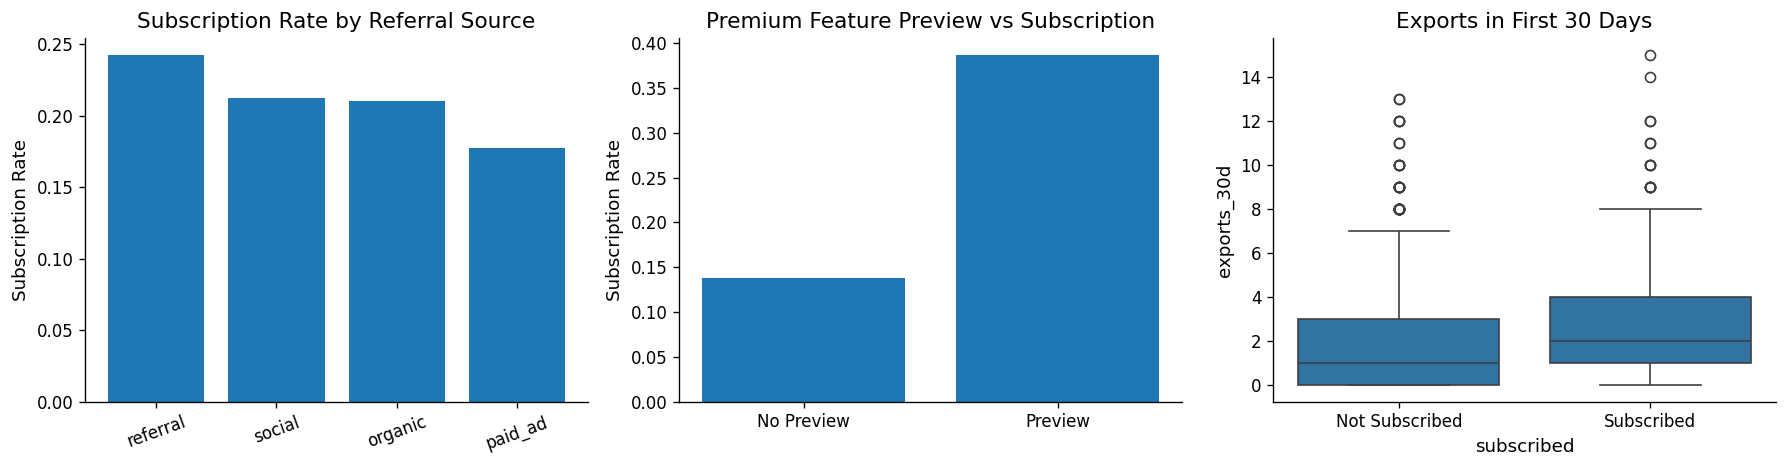

In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
referral_rate = (
    df_sub
    .groupby("referral_source")['subscribed']
    .mean()
    .sort_values(ascending=False)
)

axes[0].bar(referral_rate.index, referral_rate.values)
axes[0].set_title("Subscription Rate by Referral Source")
axes[0].set_ylabel("Subscription Rate")
axes[0].tick_params(axis='x', rotation=20)

# Plot 2 — YOUR CODE
preview_rate = (
    df_sub.groupby("used_premium_feature_preview")["subscribed"]
    .mean()
)

axes[1].bar(
    ["No Preview", "Preview"],
    preview_rate.values
)
axes[1].set_title('Premium Feature Preview vs Subscription')
axes[1].set_ylabel("Subscription Rate")

# Plot 3 — YOUR CODE
sns.boxplot(
    data=df_sub,
    x="subscribed",
    y='exports_30d',
    ax=axes[2]
)

axes[2].set_xticklabels(['Not Subscribed', 'Subscribed'])
axes[2].set_title("Exports in First 30 Days")

plt.tight_layout()
plt.show()


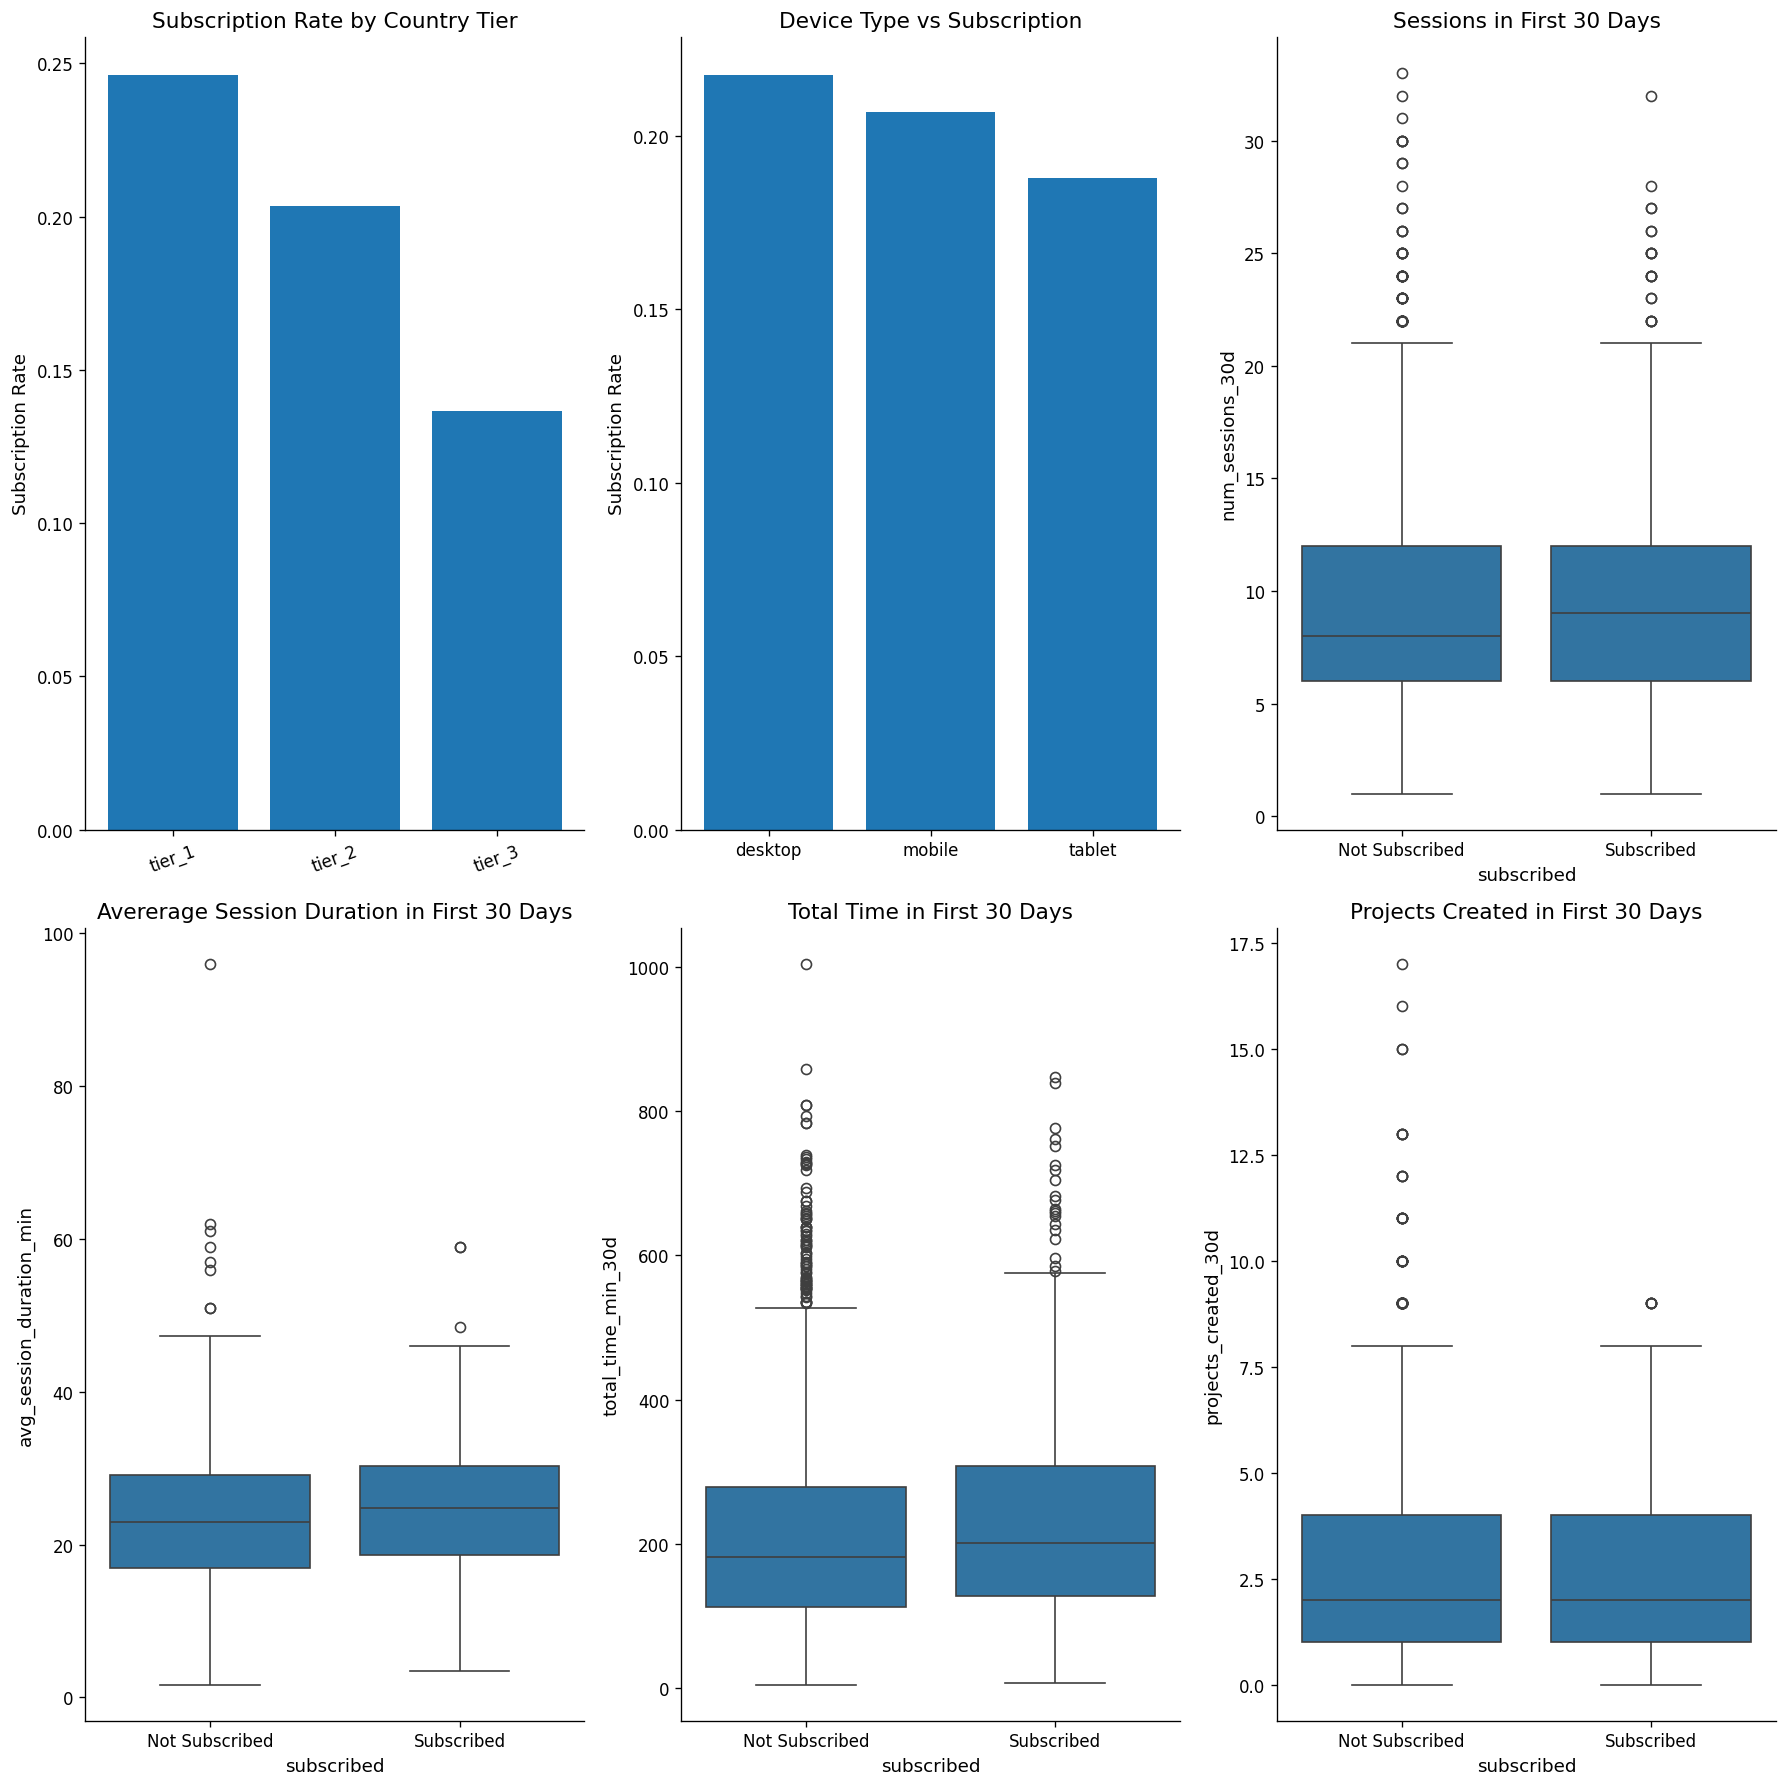

In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(2, 3, figsize=(15, 15))

# Plot 1 — YOUR CODE
country_t = (
    df_sub
    .groupby("country_tier")['subscribed']
    .mean()
    .sort_values(ascending=False)
)

axes[0][0].bar(country_t.index, country_t.values)
axes[0][0].set_title("Subscription Rate by Country Tier")
axes[0][0].set_ylabel("Subscription Rate")
axes[0][0].tick_params(axis='x', rotation=20)

# Plot 2 — YOUR CODE
device = (
    df_sub.groupby("device_type")["subscribed"]
    .mean()
)

axes[0][1].bar(
    device.index,
    device.values
)
axes[0][1].set_title('Device Type vs Subscription')
axes[0][1].set_ylabel("Subscription Rate")

# Plot 3 — YOUR CODE
sns.boxplot(
    data=df_sub,
    x="subscribed",
    y='num_sessions_30d',
    ax=axes[0][2]
)

axes[0][2].set_xticklabels(['Not Subscribed', 'Subscribed'])
axes[0][2].set_title("Sessions in First 30 Days")


# Plot 4 — YOUR CODE
sns.boxplot(
    data=df_sub,
    x="subscribed",
    y='avg_session_duration_min',
    ax=axes[1][0]
)

axes[1][0].set_xticklabels(['Not Subscribed', 'Subscribed'])
axes[1][0].set_title("Avererage Session Duration in First 30 Days")

# Plot 5 — YOUR CODE
sns.boxplot(
    data=df_sub,
    x="subscribed",
    y='total_time_min_30d',
    ax=axes[1][1]
)

axes[1][1].set_xticklabels(['Not Subscribed', 'Subscribed'])
axes[1][1].set_title("Total Time in First 30 Days")

# Plot 6 — YOUR CODE
sns.boxplot(
    data=df_sub,
    x="subscribed",
    y='projects_created_30d',
    ax=axes[1][2]
)

axes[1][2].set_xticklabels(['Not Subscribed', 'Subscribed'])
axes[1][2].set_title("Projects Created in First 30 Days")


plt.tight_layout()
plt.show()



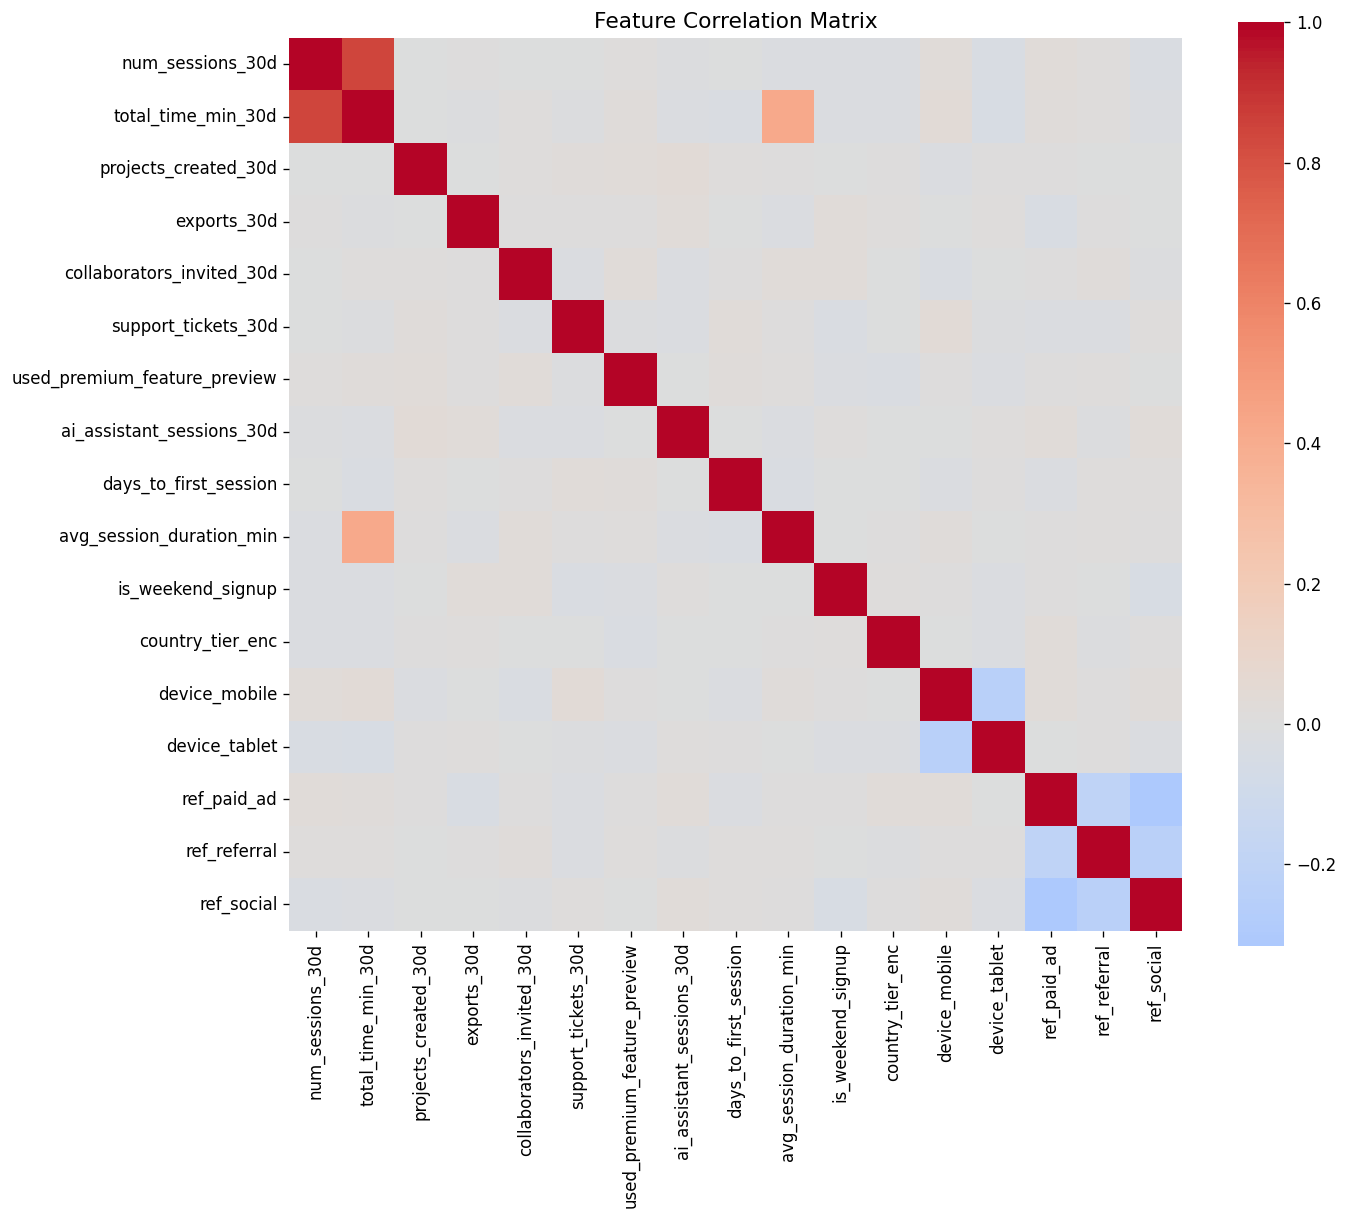

In [ ]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
corr = X_sub[numeric_features].corr()

# Plot as heatmap

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Feature Correlation Matrix')
plt.show()


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*


From the series of visualizations I made, it appears that used_premium_feature_preview, country_tier, and exports in first 30 days have strong association with whether a user subscribes or not. One slightly counterintuitive finding is that users who didn't subscribe seem to have a greater amount of projects created within their first 30 days than users who did subscribe.

It looks like num_sessions_30d strongly correlates with total_time_min_30d, which makes sense since the more sessions a user had the more total time they would have spent on Phigma. As well, num_sessions_30d correlates with avg_session_duration_min, which also makes sense because these both measure the time a person spent on Phigma. The only thing that would concern me here is average time and total time are similar measures and might have too much of an impact on what the model dictates even though they are similar measures.

One concerning correlation is that there's some correlation between mobile device users and support tickets, meaning Phigma might have performance issues on mobile devices.

### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
X_const_sub = sm.add_constant(X_sub)
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.440520
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2982
Method:                           MLE   Df Model:                           17
Date:                Mon, 06 Jul 2026   Pseudo R-squ.:                  0.1392
Time:                        05:44:24   Log-Likelihood:                -1321.6
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 3.542e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.5253      0.325     -7.772      0.000

In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
odds_ratios = np.exp(model_logit.params)

conf_int = np.exp(model_logit.conf_int())
conf_int.columns = ['Lower', 'Upper']

# Combine into a readable table and display
results = pd.DataFrame({
    "Coefficient": model_logit.params,
    "Odds Ratio": odds_ratios,
    "p-value": model_logit.pvalues,
    "Lower": conf_int['Lower'],
    "Upper": conf_int['Upper']
})

# Filter to significant only: p < 0.05

significant_results = results[results["p-value"] < 0.05].sort_values(
    by="Odds Ratio",
    ascending=False
)

display(significant_results)


,Coefficient,Odds Ratio,p-value,Lower,Upper
used_premium_feature_preview,1.469474,4.346950,4.796877e-49,3.574461,5.286385
exports_30d,0.194102,1.214220,7.102228e-19,1.163262,1.267411
support_tickets_30d,0.154681,1.167285,3.329027e-04,1.072714,1.270195
collaborators_invited_30d,0.061307,1.063226,5.872426e-03,1.017847,1.110628
avg_session_duration_min,0.031054,1.031542,2.289257e-03,1.011160,1.052335
days_to_first_session,-0.092729,0.911440,1.612644e-11,0.887182,0.936362
country_tier_enc,-0.356563,0.700078,5.073127e-08,0.615806,0.795882
const,-2.525339,0.080031,7.698095e-15,0.042335,0.151294


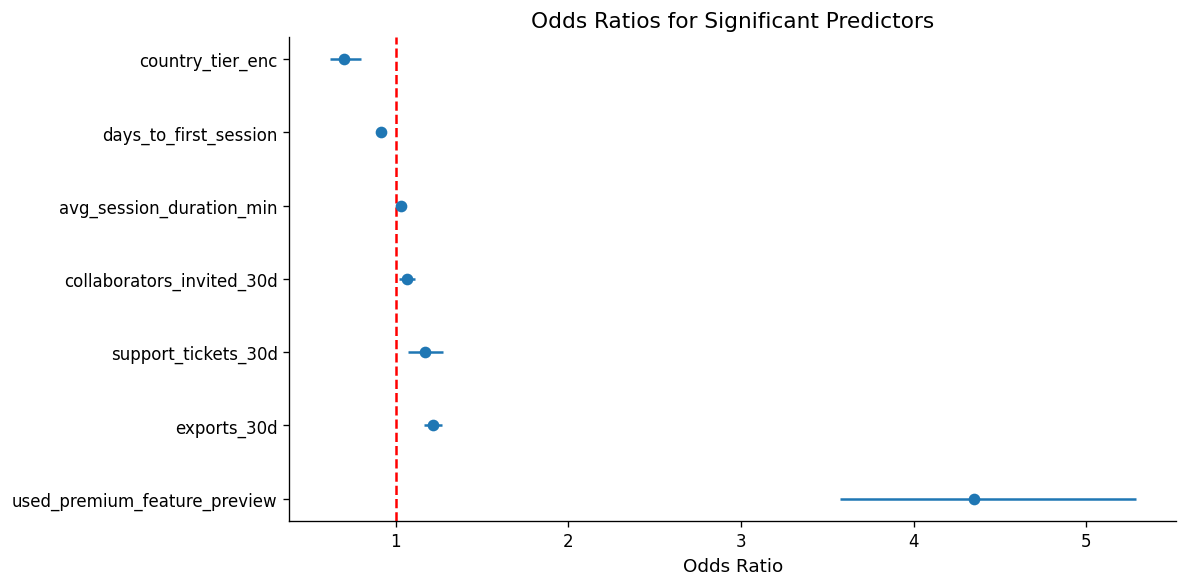

In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude

plot_df = significant_results.drop(index="const", errors="ignore")

plt.figure(figsize=(10, max(5, len(plot_df) * 0.4)))

plt.errorbar(
    plot_df['Odds Ratio'],
    plot_df.index,
    xerr=[
        plot_df['Odds Ratio'] - plot_df['Lower'],
        plot_df['Upper'] - plot_df['Odds Ratio']
    ],
    fmt='o'
)

plt.axvline(1, color='red', linestyle='--')

plt.xlabel('Odds Ratio')
plt.title('Odds Ratios for Significant Predictors')

plt.tight_layout()
plt.show()

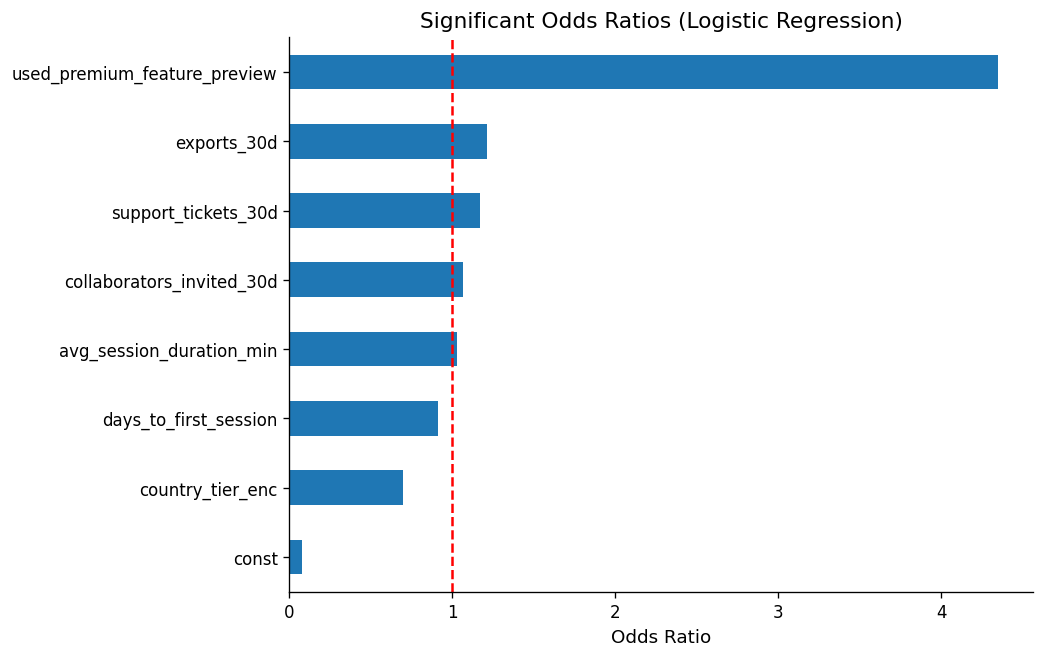

In [ ]:
#For me to understand better because I don't like the forest plot
plt.figure(figsize=(8,6))

significant_results['Odds Ratio'].sort_values().plot(kind='barh')
plt.axvline(1, color='red', linestyle='--')
plt.title('Significant Odds Ratios (Logistic Regression)')
plt.xlabel('Odds Ratio')
plt.show()

**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*


With an odds ratio of 4.35, viewers who previewed a premium feature were much more likely to subscribe than viewers who did not preview a premium feature. This means users who previewed a premium feature had 4.35 times the odds of subscribing.

The market tier based on country has an odds ratio of 0.70, meaning that each increase in country tier decreases the odds of subscribing by 30%.

The number of exports within the first 30 days also had an impact on subscription status, with each one unit increase in number of exports increasing the odds of subscribing by 21% (odds ratio of 1.21).

What surprised me is how little country_tier ended up impacting whether or not a user subscribes to Phigma. Earlier in the EDA visualizations, it seemed like this would have a large impact on subscription status because subscription rate differed a significant amount depending on country_tier. Therefore, I'm surprised to see that it doesn't actually make as much of an impact as I thought.

### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
X_train, X_test, y_train, y_test = train_test_split(
     X_sub,
     y_sub,
     test_size=0.2,
     random_state=42,
     stratify=y_sub
 )

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


Train: (2400, 17)  |  Test: (600, 17)
Train positive rate: 0.208  |  Test positive rate: 0.208


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)

#Predictions
y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


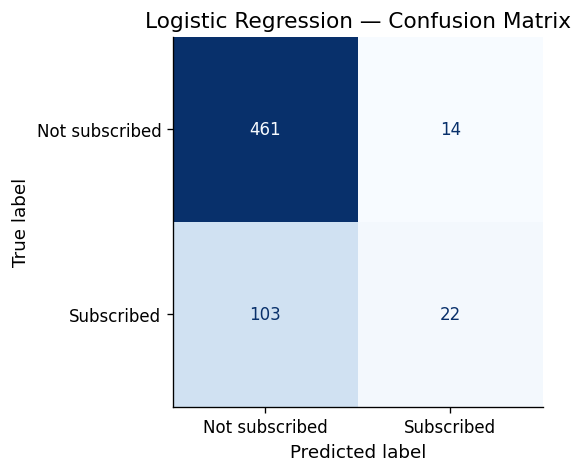

In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not subscribed', 'Subscribed']
    )

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()


In [ ]:
# YOUR CODE HERE
# Classification report
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Not subscribed', 'Subscribed']
    ))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.61      0.18      0.27       125

      accuracy                           0.81       600
     macro avg       0.71      0.57      0.58       600
  weighted avg       0.77      0.81      0.76       600

ROC-AUC: 0.7375


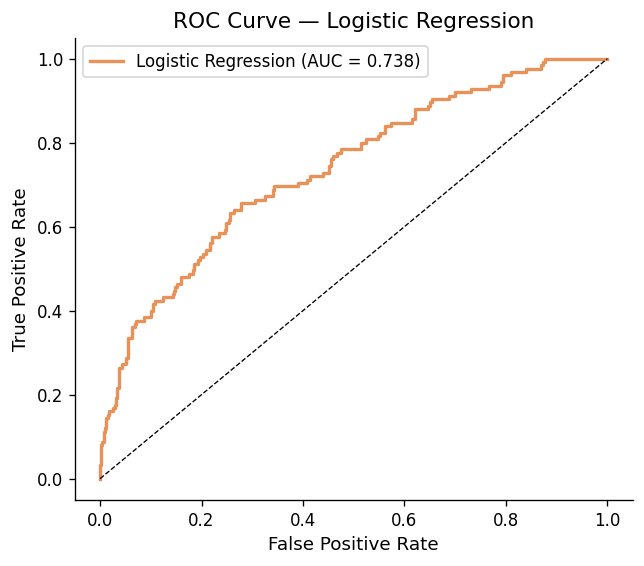

In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    fpr_lr,
    tpr_lr,
    color=ACCENT,
    lw=2,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})'
    )

ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.show()


**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


Only about 20% of users end up subscribing, so the dataset by default is unbalanced. Because of this, ROC-AUC is probably the most important metric given the class imbalance. It measures how well the model distinguishes between users who subscribed and users who didn't subscribe across different features without being influenced too much by the features with the most impact. Recall can also be important if it's important to identify subscribers.

The confusion matrix shows that the model predicted 103 false negatives, users that are subscribed but the model classified as not subscribed. It correctly predicted 461 non subscribers and 22 subscribers. There were 14 false positives that are unsubscribed but the model classified as subscribed. From Phigma's perspective, false negatives are missed opportunities because these users need to be targeted for more marketing or retention. Missing these subscribers means that Phigma overlooks customers who would have subscribed, and this costs them a subscription.

---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


I'm going to be using a support vector machine (SVM) as my model.

**✏️ Your chosen model:** `[Support Vector Machine (SVM)]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


An SVM learns from the training data by finding the boundary that separates the two classes. During the training process SVM finds the ideal boundary that will minimize classification mistakes and also stay far away from training examples (these are support vectors). I chose SVM because this model can have more complex decision boundaries. I want to see if an SVM works better on this dataset if the relationship between the data and subscriptions isn't linear.

### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
clf_c = SVC(probability = True, random_state=42)   # add random_state if supported
#probability must be True

#training
clf_c.fit(X_train, y_train)

#predictions
y_pred_c = clf_c.predict(X_test)
y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


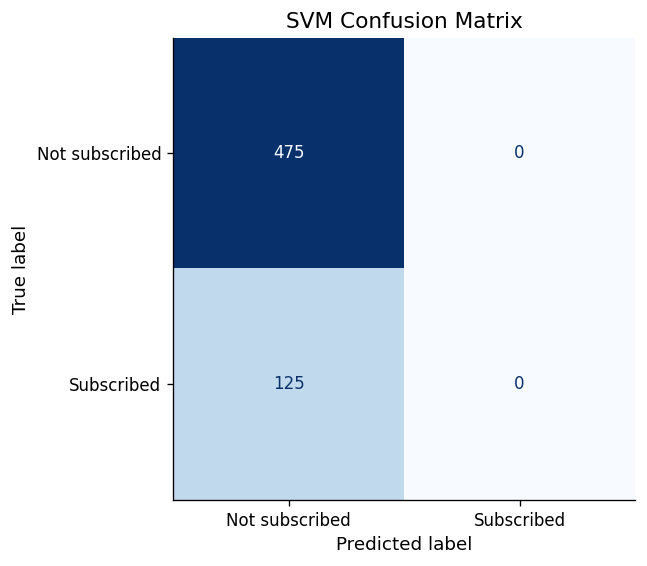

In [ ]:
# YOUR CODE HERE
# Confusion matrix

cm_c = confusion_matrix(y_test, y_pred_c)

fig, ax = plt.subplots(figsize=(5, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_c,
    display_labels=['Not subscribed', 'Subscribed']

)

disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title("SVM Confusion Matrix")

plt.show()

In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC

print(classification_report(y_test, y_pred_c))

auc_c = roc_auc_score(y_test, y_prob_c)
print(f'FOC-AUC Score: {auc_c:.4f}')

              precision    recall  f1-score   support

           0       0.79      1.00      0.88       475
           1       0.00      0.00      0.00       125

    accuracy                           0.79       600
   macro avg       0.40      0.50      0.44       600
weighted avg       0.63      0.79      0.70       600

FOC-AUC Score: 0.3966


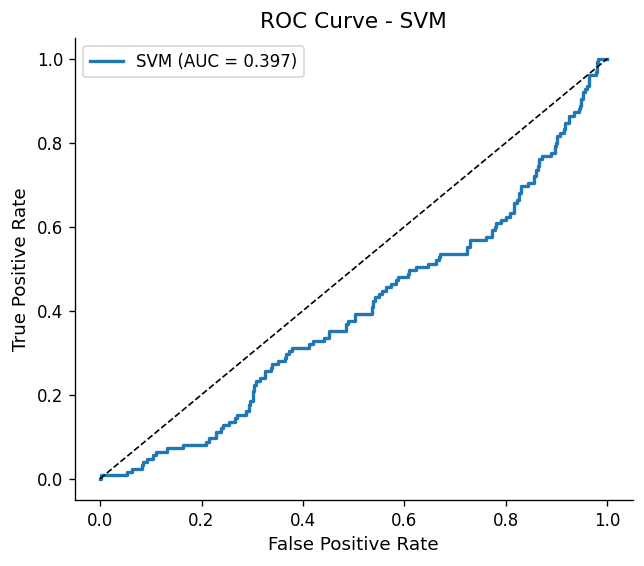

In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)

fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)

fig, ax=plt.subplots(figsize=(6,5))

ax.plot(
    fpr_c,
    tpr_c,
    lw=2,
    label=f"SVM (AUC = {auc_c:.3f})"
)

ax.plot([0,1], [0,1], 'k--', lw=1)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - SVM')

ax.legend()
plt.show()

### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table

metrics = {
     'Model': [
         'Logistic Regression',
         'SVM'
         ],
     'ROC-AUC': [
         auc_lr,
         auc_c
     ],
     'F1 (class 1)': [
         f1_score(y_test, y_pred_lr),
         f1_score(y_test, y_pred_c)
     ],
     'Precision (class 1)': [
         precision_score(y_test, y_pred_lr),
         precision_score(y_test, y_pred_c)
     ],
     'Recall (class 1)': [
         recall_score(y_test, y_pred_lr),
         recall_score(y_test, y_pred_c)
     ],
 }

pd.DataFrame(metrics).set_index('Model').round(4)

#comparisons for class 1: subscribed


,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.7375,0.2733,0.6111,0.176
SVM,0.3966,0.0000,0.0000,0.000


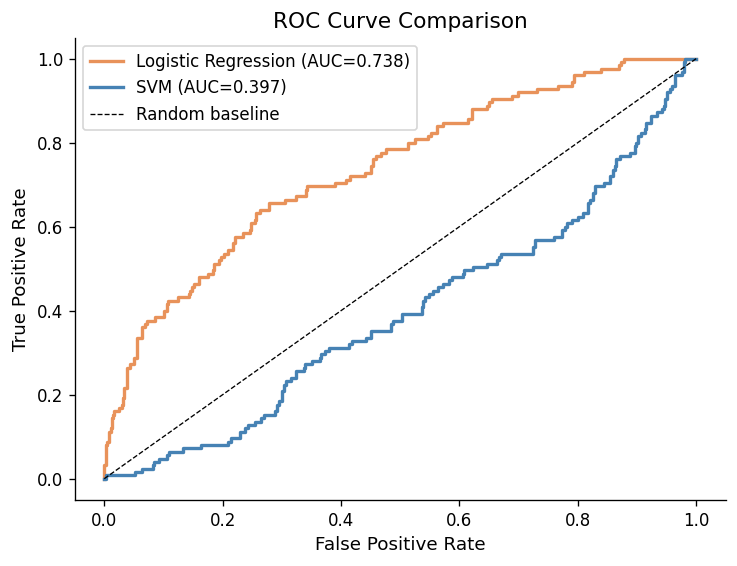

In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    fpr_lr,
    tpr_lr,
    color=ACCENT,
    lw=2,
    label=f'Logistic Regression (AUC={auc_lr:.3f})'
    )

ax.plot(
    fpr_c,
    tpr_c,
    color='steelblue',
    lw=2,
    label=f'SVM (AUC={auc_c:.3f})'
    )

ax.plot(
    [0,1],
    [0,1], 'k--',
    lw=0.8,
    label='Random baseline'
    )

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')

ax.legend()
plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


The SVM performed poorly and so the logistic regression model is the winner here. The ROC-AUC of the SVM is 0.397 compared to the 0.738 of the logistic regression model. Additionally, The SVM scored 0.00 for F1, precision, and accuracy. My guess is that because of the class imbalance, the SVM wasn't able to accurately find the best boundary between classes. As well, some of the features with weaker impact on subscription status might have made it harder for the SVM to find a good boundary and confused the model. It's also likely that logistic regression performed much better than the SVM because the majority of features had a linear relationship to subscription status.

### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
'''
# YOUR CODE HERE (BONUS)
from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale,", "auto"]
}

# Run cross-validated search on the TRAINING SET ONLY
search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1)

search.fit(X_train, y_train)

best_svm = search.best_estimator_

print(f"Best parameters: {search.best_params_}")
print(f"Best Cross-Validation AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")
'''


'\n# YOUR CODE HERE (BONUS)\nfrom sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV\n\n# Define a parameter grid relevant to your chosen model\nparam_grid = {\n    "C": [0.1, 1, 10],\n    "kernel": ["linear", "rbf", "poly"],\n    "gamma": ["scale,", "auto"]\n}\n\n# Run cross-validated search on the TRAINING SET ONLY\nsearch = GridSearchCV(\n    estimator=SVC(probability=True, random_state=42),\n    param_grid=param_grid,\n    cv=5,\n    scoring=\'roc_auc\',\n    n_jobs=-1)\n\nsearch.fit(X_train, y_train)\n\nbest_svm = search.best_estimator_\n\nprint(f"Best parameters: {search.best_params_}")\nprint(f"Best Cross-Validation AUC:     {search.best_score_:.4f}")\n\n# Evaluate tuned model on test set\n# y_pred_tuned = search.best_estimator_.predict(X_test)\n# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]\n# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")\n# print(f"Default test AUC:{auc_c:.4f}")\n# print("Did tuning meaningfully imp

I tried using GridSearchCV first, but it has a significantly longer runtime than RandomizedSearchCV. I'm going to switch to using RandomizedSearchCV instead.

In [ ]:
# Define parameter distributions

### AI GENERATED BY CHATGPT ###
### BEGIN ###
param_dist = {
    "C": loguniform(0.01, 100),
    "gamma": loguniform(0.0001, 1)
    # "kernel": ["rbf", "linear", "poly"],
    # "degree": [2, 3, 4]
}

# Base model
svm = SVC(
    kernel = "rbf",
    probability=True,
    random_state=42
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

### END ###

#Fit search
random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print(f"\nBest Cross-Validation ROC-AUC: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters:
{'C': np.float64(21.368329072358772), 'gamma': np.float64(0.0007068974950624604)}

Best Cross-Validation ROC-AUC: 0.6399


In [ ]:
best_svm = random_search.best_estimator_

# Predictions
y_pred_tuned = best_svm.predict(X_test)
y_prob_tuned = best_svm.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_tuned))

auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"\nTest ROC-AUC: {auc_tuned:.4f}")

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.99      0.88       475
           1       0.33      0.02      0.03       125

    accuracy                           0.79       600
   macro avg       0.56      0.50      0.46       600
weighted avg       0.70      0.79      0.70       600


Test ROC-AUC: 0.6371


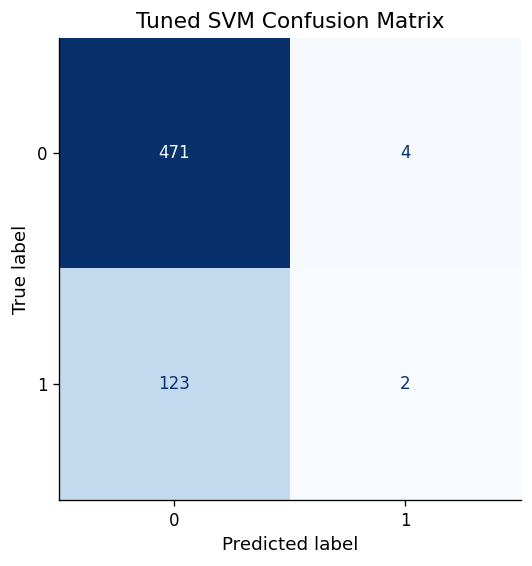

In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_svm.classes_
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Tuned SVM Confusion Matrix")

plt.show()

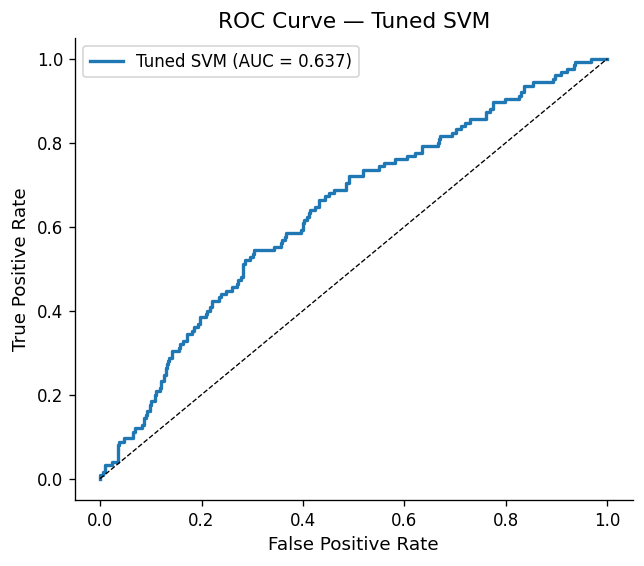

In [ ]:
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

fig, ax = plt.subplots(figsize=(6,5))

ax.plot(
    fpr_tuned,
    tpr_tuned,
    lw=2,
    label=f"Tuned SVM (AUC = {auc_tuned:.3f})"
)

ax.plot([0,1], [0,1], 'k--', lw=0.8)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Tuned SVM")

ax.legend()

plt.show()

In [ ]:
comparison_tuned = pd.DataFrame({
    "Model": [
        "Default SVM",
        "Tuned SVM"
    ],
    "ROC-AUC": [
        auc_c,
        auc_tuned
    ],
    "F1": [
        f1_score(y_test, y_pred_c),
        f1_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_c),
        precision_score(y_test, y_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_c),
        recall_score(y_test, y_pred_tuned)
    ]
})

comparison_tuned.set_index("Model").round(4)

,ROC-AUC,F1,Precision,Recall
Model,,,,
Default SVM,0.3966,0.0000,0.0000,0.000
Tuned SVM,0.6371,0.0305,0.3333,0.016


Hyperparameter training ended up making a slight difference, raising the ROC-AUC from 0.3966 to 0.6371. This is a much better score meaning the default model probably had settings that didn't work well with this dataset. The F1 increased slightly to 0.0305, F1 at 0.3333, and recall at 0.016. These metrics are still low and are weaker than the logistic regression model. It still has the same problem of overclassifying users as unsubscribed. However, it's still better than the original SVM model.

---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
